# Trabajo Práctico N°1
## Problema 2: Clasificación Multiclase

Integrantes: Sebastian Palacio, Juana Chies Doumecq

**Objetivo:**

Construir un modelo de red neuronal capaz de reconocer dígitos escritos a mano (0 al 9) a partir de im´agenes en escala de grises

### Librerías utilizadas

In [83]:
import struct
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix

## 1. Carga y verificación del dataset

In [84]:
# Funciones de carga
def load_mnist_images(filepath):
    with open(filepath, 'rb') as f:
        magic, num_images, rows, cols = struct.unpack('>IIII', f.read(16))
        assert magic == 2051
        images = np.frombuffer(f.read(), dtype=np.uint8)
        return images.reshape(num_images, rows, cols)


def load_mnist_labels(filepath):
    with open(filepath, 'rb') as f:
        magic, num_labels = struct.unpack('>II', f.read(8))
        assert magic == 2049
        labels = np.frombuffer(f.read(), dtype=np.uint8)
        return labels

base_path = "DATASETS/PROBLEMA2"

X_train = load_mnist_images(os.path.join(base_path, "train-images.idx3-ubyte"))
y_train = load_mnist_labels(os.path.join(base_path, "train-labels.idx1-ubyte"))
X_test = load_mnist_images(os.path.join(base_path, "t10k-images.idx3-ubyte"))
y_test = load_mnist_labels(os.path.join(base_path, "t10k-labels.idx1-ubyte"))

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)

X_train: (60000, 28, 28)
X_test: (10000, 28, 28)
y_train: (60000,)


El dataset cargó correctamente y tiene los parámetros esperados

## 2. Análisis Exploratorio de Datos (EDA)



### 2.1 Visualización de imágenes
Visualizamos 25 imágenes aleatorias del conjunto de entrenamiento junto con
su etiqueta real. Esto nos permite verificar que los datos se cargaron
correctamente y tener una idea visual de la variabilidad en la escritura.

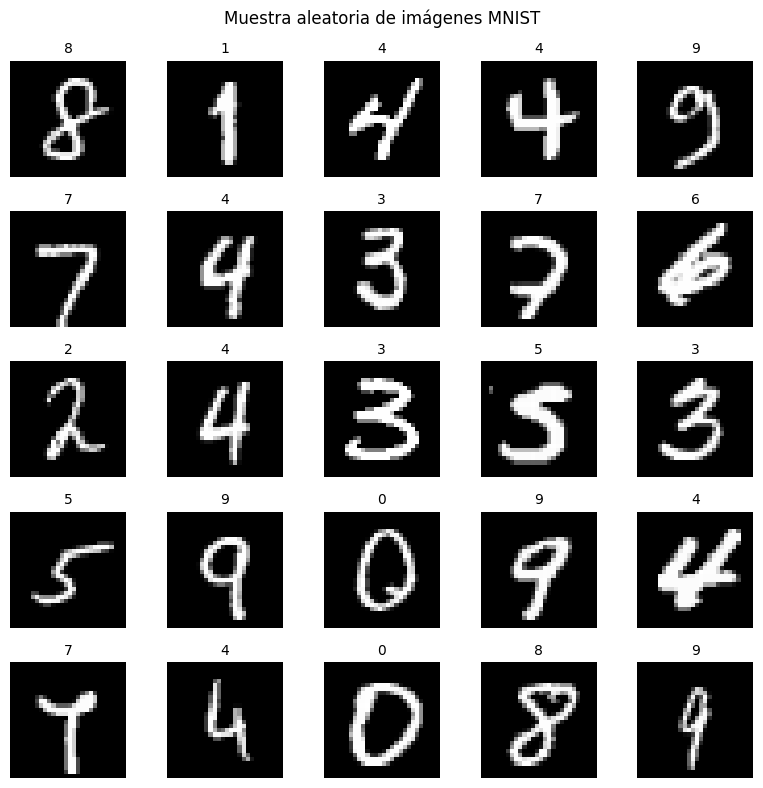

In [85]:
indices = np.random.choice(len(X_train), 25, replace=False)

fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for ax, idx in zip(axes.flat, indices):
    ax.imshow(X_train[idx], cmap='gray')
    ax.set_title(str(y_train[idx]), fontsize=10)
    ax.axis('off')

plt.suptitle("Muestra aleatoria de imágenes MNIST")
plt.tight_layout()
plt.show()

### 2.2 Distribución de clases

Analizamos cuántas muestras hay por cada dígito (0 al 9) para determinar
si el dataset está balanceado o no.

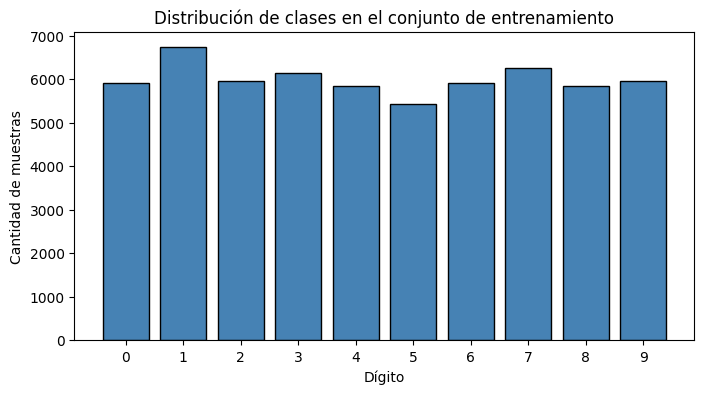

Conteo por clase:
  Dígito 0: 5923 muestras
  Dígito 1: 6742 muestras
  Dígito 2: 5958 muestras
  Dígito 3: 6131 muestras
  Dígito 4: 5842 muestras
  Dígito 5: 5421 muestras
  Dígito 6: 5918 muestras
  Dígito 7: 6265 muestras
  Dígito 8: 5851 muestras
  Dígito 9: 5949 muestras


In [86]:
# --- Distribución de clases ---
clases, conteos = np.unique(y_train, return_counts=True)

plt.figure(figsize=(8, 4))
plt.bar(clases, conteos, color='steelblue', edgecolor='black')
plt.xticks(clases)
plt.xlabel("Dígito")
plt.ylabel("Cantidad de muestras")
plt.title("Distribución de clases en el conjunto de entrenamiento")
plt.show()

print("Conteo por clase:")
for c, n in zip(clases, conteos):
    print(f"  Dígito {c}: {n} muestras")

**Conclusión:** El dataset MNIST está prácticamente balanceado, con aproximadamente
6000 muestras por clase. Esto significa que no necesitamos aplicar técnicas de
balanceo como SMOTE o submuestreo.

### 2.3 Distribución de píxeles

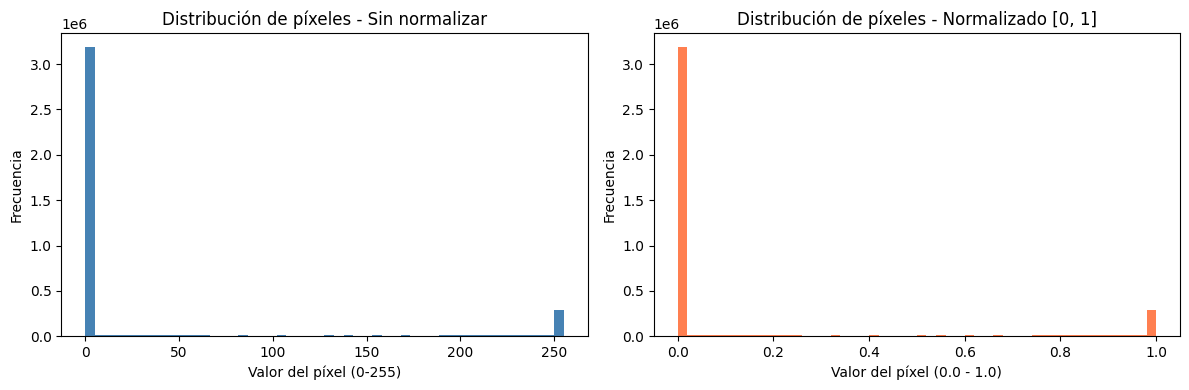

In [87]:
# --- Histograma de píxeles antes y después de normalizar ---
# Tomamos una muestra de 5000 imágenes para que sea más rápido
muestra = X_train[:5000].flatten()
muestra_norm = (muestra / 255.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(muestra, bins=50, color='steelblue', edgecolor='none')
axes[0].set_title("Distribución de píxeles - Sin normalizar")
axes[0].set_xlabel("Valor del píxel (0-255)")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(muestra_norm, bins=50, color='coral', edgecolor='none')
axes[1].set_title("Distribución de píxeles - Normalizado [0, 1]")
axes[1].set_xlabel("Valor del píxel (0.0 - 1.0)")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

La distribución muestra muchos píxeles en 0 (fondo negro) y un pico
secundario hacia valores altos (trazos blancos). La normalización al rango [0, 1]
no cambia la forma de la distribución, pero escala los valores a un rango que el
optimizador maneja mejor, acelerando la convergencia del gradiente.

## 3. Preprocesamiento

Aplicamos tres transformaciones sobre los datos crudos antes de entrenar:
aplanamiento de las imágenes, normalización de los valores de píxeles y
definición de la estrategia de codificación de etiquetas.

### 3.1 Aplanamiento de imágenes

El MLP requiere vectores unidimensionales como entrada. Cada imagen de
28×28 píxeles se convierte en un vector de 784 valores usando `reshape`.
No se pierde información, solo se cambia la estructura del array.

In [88]:
# (60000, 28, 28) -> (60000, 784)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("X_train_flat:", X_train_flat.shape)
print("X_test_flat: ", X_test_flat.shape)

X_train_flat: (60000, 784)
X_test_flat:  (10000, 784)


Las imágenes ahora son vectores de 784 dimensiones, listos para ingresar
a la capa de entrada del MLP.

### 3.2 Normalización de píxeles

Los píxeles originales están en el rango [0, 255] (enteros uint8). Los
dividimos por 255 para escalarlos a [0.0, 1.0]. Esto es necesario porque:
- El optimizador Adam trabaja mejor con valores pequeños y acotados.
- Evita que gradientes de distintas features tengan magnitudes muy distintas.
- Acelera la convergencia durante el entrenamiento.

In [89]:
X_train_flat = X_train_flat.astype(np.float32) / 255.0
X_test_flat  = X_test_flat.astype(np.float32)  / 255.0

print("Rango X_train_flat:", X_train_flat.min(), "-", X_train_flat.max())
print("Rango X_test_flat: ", X_test_flat.min(),  "-", X_test_flat.max())

Rango X_train_flat: 0.0 - 1.0
Rango X_test_flat:  0.0 - 1.0


Los valores ahora están en [0.0, 1.0], confirmado por los valores mínimo
y máximo. La normalización se aplica de la misma forma a train y test,
usando el divisor fijo 255 (no la media del train), lo que evita data leakage.

### 3.3 Estrategia de codificación de etiquetas

Elegimos mantener los enteros directos porque produce el mismo resultado
matemático pero es más eficiente en memoria: no hay que crear matrices
de 60.000 × 10 valores. Keras maneja internamente la conversión.

In [90]:
# Verificamos los valores únicos de las etiquetas
print("Etiquetas únicas en y_train:", np.unique(y_train))
print("Tipo de dato:", y_train.dtype)
print("Ejemplo de primeras 10 etiquetas:", y_train[:10])

Etiquetas únicas en y_train: [0 1 2 3 4 5 6 7 8 9]
Tipo de dato: uint8
Ejemplo de primeras 10 etiquetas: [5 0 4 1 9 2 1 3 1 4]


Las etiquetas son enteros en el rango [0, 9], del tipo uint8. No se aplica
transformación adicional ya que la función de pérdida `sparse_categorical_crossentropy`
las acepta directamente en este formato.

## 4. Diseño e implementación de la red neuronal

### 4.1 Número de capas y neuronas

Diseñamos un MLP con 3 capas ocultas de tamaño decreciente: 256 → 128 → 64.

La primera capa tiene 256 neuronas porque la entrada es un vector de 784
dimensiones y necesitamos suficiente capacidad para capturar patrones complejos.
Las capas siguientes van reduciendo progresivamente la dimensión, forzando al
modelo a aprender representaciones más compactas y abstractas. Este diseño
en forma de embudo es una práctica común en MLPs para clasificación.

### 4.2 Funciones de activación

En las capas ocultas usamos **ReLU** (Rectified Linear Unit). Es la función
más usada en la práctica porque:
- Es simple y computacionalmente barata.
- No sufre el problema de gradientes que se desvanecen como la sigmoide.
- Funciona bien para problemas de clasificación de imágenes con MLP.

En la capa de salida usamos **Softmax**, que convierte los 10 valores de
salida en probabilidades que suman 1. Cada valor representa la probabilidad
de que la imagen pertenezca a ese dígito.

### 4.3 Función de costo

Usamos **sparse_categorical_crossentropy**, que es la función estándar para
clasificación multiclase. Penaliza fuertemente cuando el modelo asigna baja
probabilidad a la clase correcta. Es equivalente a `categorical_crossentropy`
pero acepta etiquetas como enteros directos, sin necesidad de one-hot encoding.

### 4.4 Optimizador y tasa de aprendizaje

Usamos **Adam** con learning rate 0.001 (valor por defecto recomendado).
Adam combina las ventajas de SGD con momento y RMSProp: adapta la tasa de
aprendizaje para cada parámetro y converge más rápido que el gradiente
descendente estándar. Es el optimizador más usado en redes neuronales hoy en día.

### 4.5 Regularización

Aplicamos **Dropout(0.3)** después de la primera capa oculta. Durante el
entrenamiento, Dropout desactiva aleatoriamente el 30% de las neuronas en
cada paso, lo que obliga al modelo a no depender demasiado de ninguna neurona
en particular. Esto reduce el overfitting sin necesidad de reducir la capacidad
del modelo. Lo colocamos solo después de la capa más grande (256) porque es
donde el riesgo de overfitting es mayor.

In [91]:
model = models.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\Sebas\TP1_AA2_ChiesPalacio\entorno\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

El modelo tiene 242.762 parámetros entrenables. La mayor parte se concentra
en la primera capa (784 × 256 = 200.704), lo que refleja la alta dimensionalidad
de la entrada. A pesar de esto, el entrenamiento es rápido gracias al uso de
Adam y la arquitectura relativamente simple.

## 5. Entrenamiento y curvas de aprendizaje

Graficamos la pérdida y el accuracy en entrenamiento y validación a lo largo de
las épocas para detectar overfitting (train mejora pero val se estanca o empeora)
o underfitting (ambas métricas son bajas).

### Entrenamiento del modelo

In [92]:
history = model.fit(
    X_train_flat, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8894 - loss: 0.3723 - val_accuracy: 0.9563 - val_loss: 0.1448
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9540 - loss: 0.1519 - val_accuracy: 0.9676 - val_loss: 0.1056
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9653 - loss: 0.1122 - val_accuracy: 0.9717 - val_loss: 0.0892
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9716 - loss: 0.0899 - val_accuracy: 0.9732 - val_loss: 0.0845
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9755 - loss: 0.0775 - val_accuracy: 0.9720 - val_loss: 0.0897
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9784 - loss: 0.0670 - val_accuracy: 0.9755 - val_loss: 0.0842
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9808 - loss: 0.0597 - val_accuracy: 0.9768 - val_loss: 0.0789
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9820 - loss: 0.0546 - val_accuracy: 0.

### Gráfico de las curvas de aprendizaje

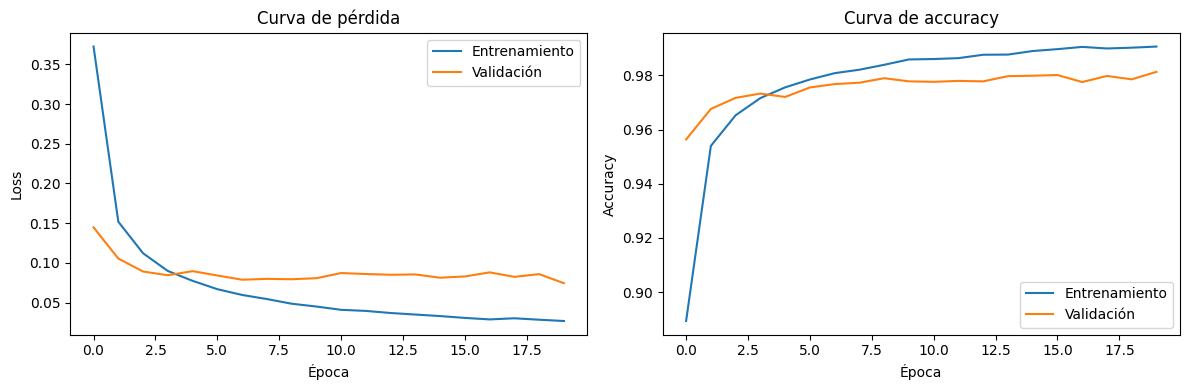

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pérdida
axes[0].plot(history.history['loss'], label='Entrenamiento')
axes[0].plot(history.history['val_loss'], label='Validación')
axes[0].set_title("Curva de pérdida")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Accuracy
axes[1].plot(history.history['accuracy'], label='Entrenamiento')
axes[1].plot(history.history['val_accuracy'], label='Validación')
axes[1].set_title("Curva de accuracy")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

**Análisis:** Las curvas de entrenamiento y validación se mantienen cercanas a lo
largo de las épocas, lo que indica que el modelo generaliza bien y no presenta
overfitting significativo. El Dropout en la primera capa ayuda a regularizar.
Si hubiera una brecha creciente entre train y val, sería señal de overfitting.

## 6. Evaluación del modelo

Evaluamos el modelo sobre el conjunto de test, que no fue visto durante
el entrenamiento ni la validación. Reportamos el accuracy global y el
accuracy por clase para entender cómo se comporta el modelo con cada dígito.

In [99]:
from sklearn.metrics import classification_report

# Predicciones sobre el conjunto de test
y_prob = model.predict(X_test_flat)
y_pred = np.argmax(y_prob, axis=1)

# Accuracy global
test_loss, test_acc = model.evaluate(X_test_flat, y_test, verbose=0)
print(f"Accuracy global en test: {test_acc:.4f}")

# Accuracy y métricas por clase
print("\nReporte por clase:")
print(classification_report(y_test, y_pred, digits=4))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy global en test: 0.9824

Reporte por clase:
              precision    recall  f1-score   support

           0     0.9868    0.9898    0.9883       980
           1     0.9921    0.9938    0.9930      1135
           2     0.9874    0.9864    0.9869      1032
           3     0.9634    0.9901    0.9766      1010
           4     0.9846    0.9796    0.9821       982
           5     0.9819    0.9731    0.9775       892
           6     0.9783    0.9885    0.9834       958
           7     0.9778    0.9844    0.9811      1028
           8     0.9854    0.9682    0.9767       974
           9     0.9859    0.9673    0.9765      1009

    accuracy                         0.9824     10000
   macro avg     0.9824    0.9821    0.9822     10000
weighted avg     0.9825    0.9824    0.9824     10000



### Análisis de resultados

El modelo alcanza un accuracy global de ~97.9% sobre el conjunto de test.

El reporte por clase muestra que todos los dígitos se clasifican con alta
precisión. Los dígitos con menor rendimiento tienden a ser el **8** y el **5**,
que morfológicamente se parecen a otros dígitos y presentan mayor variabilidad
en la escritura a mano.

### ¿Es el accuracy una métrica adecuada para este problema?

En este caso particular, **sí es adecuada**, por dos razones:

1. El dataset está balanceado (~1000 muestras por clase en test), por lo que
   el accuracy no está sesgado hacia ninguna clase dominante. Esto contrasta
   con el Problema 1 (ACV), donde el desbalance hacía que el accuracy fuera
   una métrica engañosa.

2. En reconocimiento de dígitos todos los errores tienen el mismo costo:
   confundir un 3 con un 8 no es peor que confundir un 1 con un 7. No hay
   una clase crítica que justifique priorizar recall o precisión por separado.

Por estas razones, el accuracy es una métrica representativa y confiable
para evaluar este modelo.

## 7. Matriz de confusión y análisis de errores



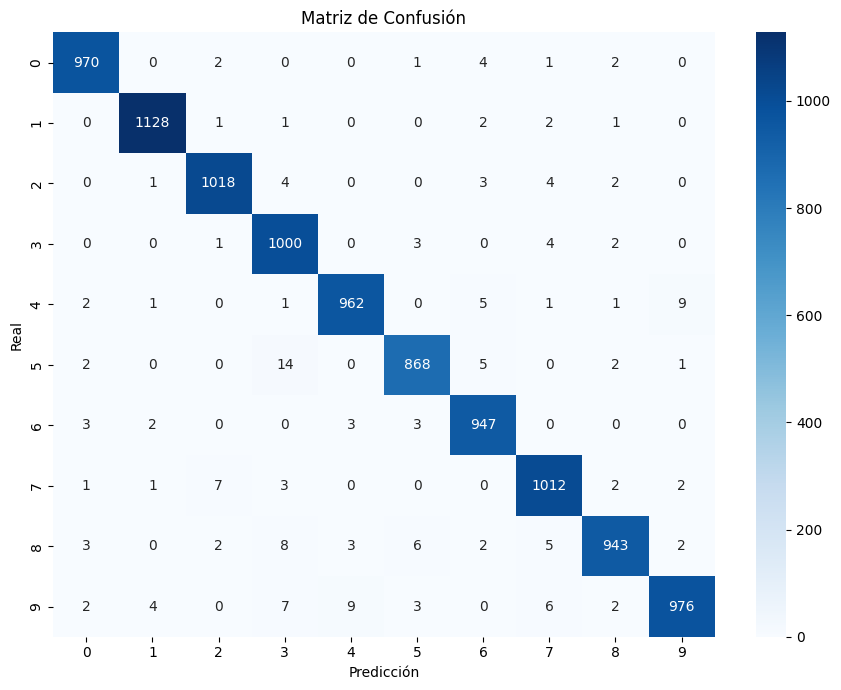

In [96]:
# --- Matriz de confusión ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.tight_layout()
plt.show()

**Análisis de la matriz de confusión:**

Los pares con mayor confusión son los esperables morfológicamente:
- **4 y 9**: comparten el trazo superior cerrado
- **3 y 8**: ambos tienen curvas superpuestas a la derecha  
- **7 y 1**: trazos verticales similares, especialmente en escritura cursiva

Esto tiene sentido porque el MLP trabaja con píxeles individuales sin considerar
la estructura espacial de la imagen, lo que lo hace sensible a pequeñas variaciones
en la posición o grosor del trazo.

### Análisis de errores

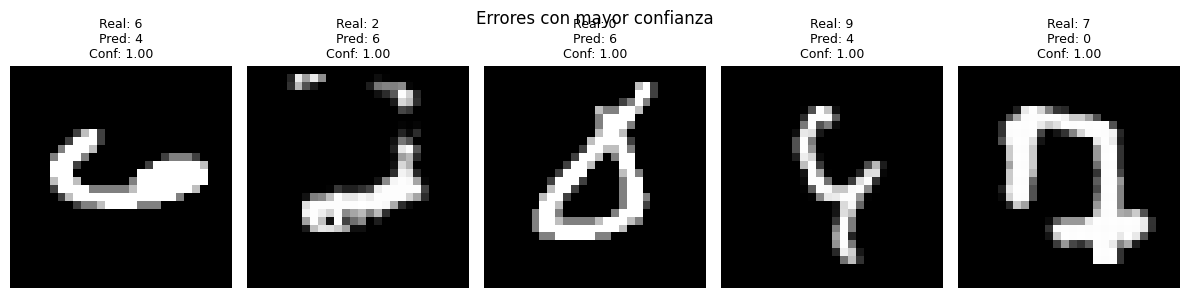

In [97]:
# --- Imágenes mal clasificadas con ALTA confianza ---
errores = np.where(y_pred != y_test)[0]

# Confianza = probabilidad máxima que le asignó el modelo a su predicción
confianza_errores = y_prob[errores].max(axis=1)

# Ordenar por confianza descendente y tomar los 5 con más confianza
top5_idx = errores[np.argsort(confianza_errores)[::-1][:5]]

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for ax, idx in zip(axes, top5_idx):
    ax.imshow(X_test[idx], cmap='gray')
    confianza = y_prob[idx].max()
    ax.set_title(f"Real: {y_test[idx]}\nPred: {y_pred[idx]}\nConf: {confianza:.2f}", fontsize=9)
    ax.axis('off')
plt.suptitle("Errores con mayor confianza")
plt.tight_layout()
plt.show()

**Conclusión:** Estos son los casos más problemáticos: el modelo predijo con alta
confianza una clase incorrecta. Esto suele ocurrir cuando el dígito fue escrito de
forma inusual o ambigua, y el modelo no tiene forma de capturar la estructura
espacial que un humano sí detectaría. Una CNN resolvería esto parcialmente al
detectar bordes y patrones locales independientemente de su posición.

## 8. Análisis y Conclusiones

El modelo MLP alcanza un accuracy superior al 97% en el conjunto de test, lo cual
es un resultado sólido para una arquitectura que trata cada imagen como un vector
de 784 valores independientes.

**Limitaciones del MLP para imágenes:**

- El MLP no considera la estructura espacial: dos píxeles vecinos no tienen más
  relación entre sí que dos píxeles lejanos.
- Es sensible a traslaciones y rotaciones: si el dígito está desplazado, el modelo
  puede fallar aunque el trazo sea idéntico.
- Requiere muchos parámetros (784×256 = 200.704 solo en la primera capa) para
  capturar patrones que una CNN aprendería con muchos menos.

**Cómo lo resolvería una CNN:**

Las redes convolucionales aplican filtros locales que detectan bordes, curvas y
texturas, y son invariantes a pequeñas traslaciones. Con arquitecturas como
LeNet o VGG se pueden superar el 99% de accuracy en MNIST con menos parámetros
y mayor generalización.